In [ ]:
import seaborn as sns
data=sns.load_dataset("iris")

In [ ]:
data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [ ]:
y=data["species"] #target
y

,species
0,setosa
1,setosa
2,setosa
3,setosa
4,setosa
...,...
145,virginica
146,virginica
147,virginica
148,virginica


In [ ]:
data["species"].value_counts() #data is balanced, very good

,count
species,
setosa,50
versicolor,50
virginica,50


# Techniques for Handling Class Imbalance in Machine Learning

Class imbalance occurs when one class has significantly more instances than another. This can negatively impact model performance, leading to biased predictions. Below are various techniques to balance the dataset.#

In [ ]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Load the dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add target column
df['Target'] = data.target  # 0 = Malignant, 1 = Benign



In [ ]:
df["Target"].value_counts() #imbalaced

,count
Target,
1,357
0,212


<Axes: xlabel='Target', ylabel='count'>

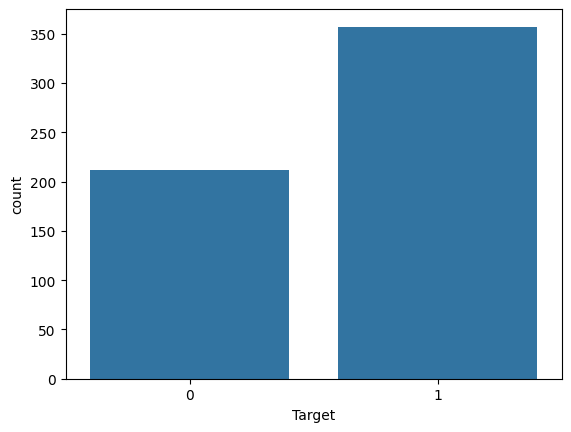

In [ ]:
sns.countplot(x=df["Target"])

In [ ]:
# Calculate Class Imbalance Ratio
maj_cls = df['Target'].value_counts().max()
min_cls = df['Target'].value_counts().min()
ratio = maj_cls / min_cls

print(f"Class Imbalance Ratio: {ratio:.2f}")


Class Imbalance Ratio: 1.68


🛠 Techniques for Different Class Imbalance Ratios  

### CIR Range & Handling Techniques  

**1.0 - 1.5 (Slight Imbalance)**  
- No major adjustments needed  
- Stratified Sampling in train-test split  

**1.5 - 3.0 (Moderate Imbalance)**  
- SMOTE (Synthetic Minority Over-sampling Technique)  

**3.0 - 10.0 (High Imbalance)**  
- SMOTE or ADASYN  

**>10.0 (Extreme Imbalance)**  
- Hybrid Approach: Over-sampling + Under-sampling  
- Anomaly Detection Methods (One-Class SVM, Isolation Forest)  


## **Introduction to SMOTE**

SMOTE (Synthetic Minority Over-sampling Technique) is a powerful oversampling method used to handle imbalanced datasets in machine learning. Instead of simply duplicating minority class samples, SMOTE generates synthetic samples by interpolating between existing minority class instances.

## **Why Use SMOTE?**

Balances the dataset, improving model performance on minority classes.

Enhances generalization by creating new, meaningful synthetic samples.

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter


In [ ]:


# Check class distribution
print("Before SMOTE:", Counter(df['Target']))

# Splitting features and target
X = df.drop(columns=['Target'])
y = df['Target']

# Apply SMOTE
smote = SMOTE(sampling_strategy='auto')

#xscaled,y
X_resampled, y_resampled = smote.fit_resample(X, y)

# Check new class distribution
print("After SMOTE:", Counter(y_resampled))

Before SMOTE: Counter({1: 357, 0: 212})
After SMOTE: Counter({0: 357, 1: 357})


<Axes: xlabel='Target', ylabel='count'>

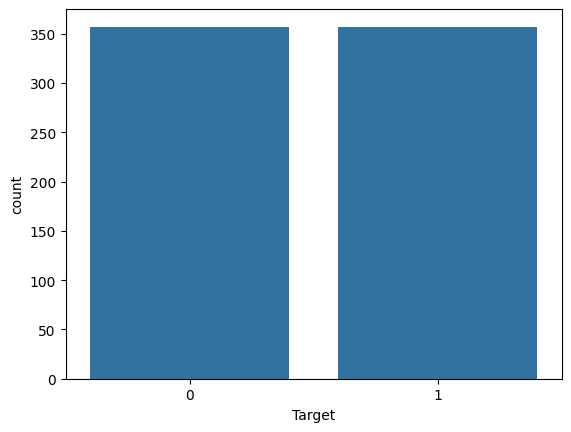

In [ ]:
import seaborn as sns
sns.countplot(x=y_resampled)

# **ADASYN (Adaptive Synthetic Sampling)** is an oversampling technique similar to SMOTE, but with a key difference:

ADASYN focuses more on harder-to-learn minority samples, generating more synthetic data in regions where the class imbalance is more severe.

In [ ]:
# Apply ADASYN
from imblearn.over_sampling import ADASYN
adasyn = ADASYN(random_state=42)
X_resampled, y_resampled = adasyn.fit_resample(X, y)

print("Original class distribution:\n", y.value_counts())
print("Resampled class distribution:\n", y_resampled.value_counts())

Original class distribution:
 Target
1    357
0    212
Name: count, dtype: int64
Resampled class distribution:
 Target
0    358
1    357
Name: count, dtype: int64


<Axes: xlabel='Target', ylabel='count'>

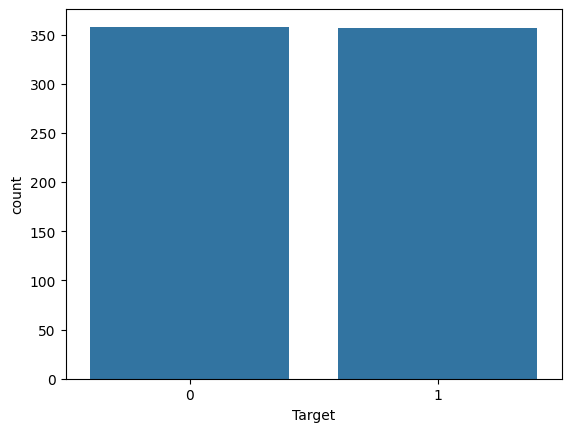

In [ ]:
import seaborn as sns
sns.countplot(x=y_resampled)

In [ ]:
from imblearn.combine import SMOTETomek
# Apply Hybrid Approach (SMOTE + Tomek Links)
smote_tomek = SMOTETomek(random_state=42)
X_resampled, y_resampled = smote_tomek.fit_resample(X, y)

print("Original class distribution:\n", y.value_counts())
print("Resampled class distribution:\n", y_resampled.value_counts())

Original class distribution:
 Target
1    357
0    212
Name: count, dtype: int64
Resampled class distribution:
 Target
0    348
1    348
Name: count, dtype: int64


<Axes: xlabel='Target', ylabel='count'>

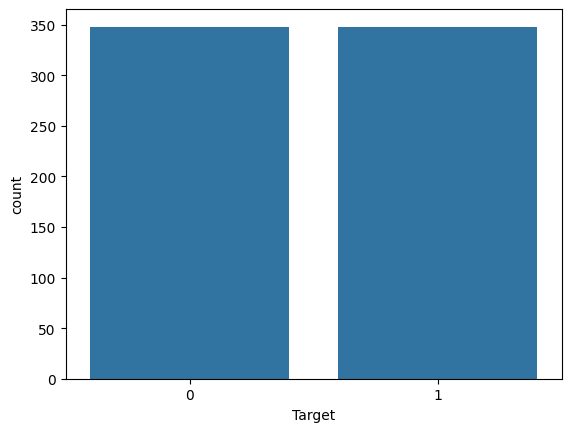

In [ ]:
import seaborn as sns
sns.countplot(x=y_resampled)

### 📊 Comparison of SMOTE, ADASYN, and Hybrid Approach  

| **Technique**          | **How It Works** | **Best for CIR Range** | **Pros** | **Cons** |  
|-----------------------|-----------------|----------------|------------------|----------------|  
| **SMOTE** (Synthetic Minority Over-sampling Technique) | Generates synthetic samples by interpolating between minority class neighbors. | **1.5 - 10** | Prevents overfitting, maintains original class distribution. | Does not consider class difficulty; may generate redundant data. |  
| **ADASYN** (Adaptive Synthetic Sampling) | Generates synthetic samples adaptively, focusing more on harder-to-learn samples. | **3 - 10** | Adaptive to class distribution, improves decision boundary. | Can introduce noise if too many difficult samples are synthesized. |  
| **Hybrid (SMOTE + Tomek/ENN)** | Combines over-sampling (e.g., SMOTE) and under-sampling (e.g., Tomek Links or ENN) to balance the dataset. | **>10** (Extreme Imbalance) | Reduces overfitting, removes noise and redundant data. | Risk of losing useful data during under-sampling. |  

### 🔥 **Key Takeaways:**  
✅ **Use SMOTE** for a moderate imbalance when a simple oversampling technique is sufficient.  
✅ **Use ADASYN** if the dataset has complex decision boundaries and difficult-to-learn samples.  
✅ **Use Hybrid (SMOTE + Under-sampling)** when dealing with extreme class imbalance (>10 CIR) to avoid excessive synthetic data.  


In [ ]:
pandas
numpy
matplotlib
seaborn
sklearn
imblearn
